## Project Title
---------------------Car Fuel Efficiency Prediction---------------

In [55]:
#  import all the library needed in this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [3]:
# Load the dataset

url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df=pd.read_csv(url)

In [4]:
# Now look the 5 row
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [5]:
# check the row and column
df.shape

(398, 9)

In [7]:
# Check column name
column=df.columns
for x in column:
  print(x)

mpg
cylinders
displacement
horsepower
weight
acceleration
model_year
origin
name


In [8]:
# check data types
print(df.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [10]:
# check missing values
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [15]:
# Statistical Summary
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [16]:
# lets find the problem
df['horsepower'].unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [21]:
df['horsepower'].dtypes

dtype('float64')

In [22]:
# Handle the misssing value
df['horsepower']=df['horsepower'].fillna(
    df['horsepower'].median()
)

In [23]:
# check again to verfiy
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [24]:
# Decide Feature

features=[
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year"
]

target="mpg"

In [25]:
x=df[features]  # inputs data
y=df[target]    # Correct Answer

In [26]:
# Check x and y
x.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year
0,8,307.0,130.0,3504,12.0,70
1,8,350.0,165.0,3693,11.5,70
2,8,318.0,150.0,3436,11.0,70
3,8,304.0,150.0,3433,12.0,70
4,8,302.0,140.0,3449,10.5,70


In [27]:
y.head()

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


In [28]:
#  train test and split the data

x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
# Check the Shapes

print("x-train :",x_train.shape)
print("x-test :",x_test.shape)

print("y_train :",y_train.shape)
print("y_test :",y_test.shape)

x-train : (318, 6)
x-test : (80, 6)
y_train : (318,)
y_test : (80,)


In [31]:
# Now train the model By using Linear Regression

model=LinearRegression()

In [32]:
model.fit(x_train,y_train)

LinearRegression()

In [33]:
# make a predictions
y_pred=model.predict(x_test)

In [51]:
# Lets compare
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results["Error"] = results["Actual"] - results["Predicted"]

print(results.head(10))

   Actual  Predicted     Error
0    33.0  31.530425  1.469575
1    28.0  30.710936 -2.710936
2    19.0  21.759651 -2.759651
3    13.0  17.004440 -4.004440
4    14.0  12.613165  1.386835
5    27.0  26.215144  0.784856
6    24.0  28.912845 -4.912845
7    13.0   9.207272  3.792728
8    17.0  17.219187 -0.219187
9    21.0  22.718517 -1.718517


In [39]:
# MAE = Mean Absolute Error
mae=mean_absolute_error(y_test,y_pred)
print("MAE :",mae)

MAE : 2.4667808004520344


In [40]:
# MSE = Mean Squared Error
mse=mean_squared_error(y_test, y_pred)
print("MSE :",mse)

MSE : 9.440068465263394


In [41]:
# RMSE = Root Mean Squared Error

rmse=np.sqrt(mse)
print("RMSE :",rmse)

RMSE : 3.072469440899843


In [42]:
# R2 Score

r2=r2_score(y_test,y_pred)
print("R2 Score :",r2)

R2 Score : 0.8244245330943356


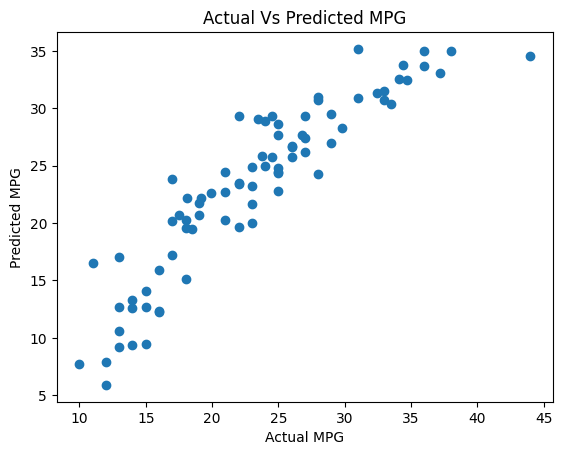

In [43]:
# visualize Actual Vs Predicted

plt.scatter(y_test,y_pred)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual Vs Predicted MPG")

plt.show()

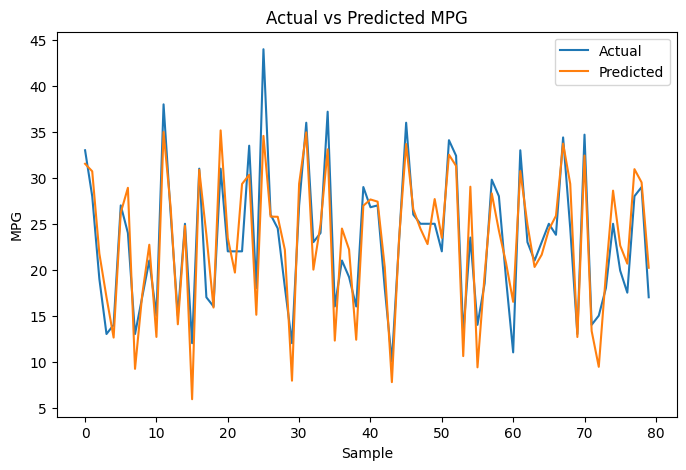

In [44]:
# plot the regression relationship
plt.figure(figsize=(8, 5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.xlabel("Sample")
plt.ylabel("MPG")
plt.title("Actual vs Predicted MPG")

plt.legend()
plt.show()

In [45]:
print(model.coef_)

[ 0.06904916  0.00160356  0.00289823 -0.0070437   0.08061413  0.80136485]


In [46]:
print(model.intercept_)

-18.70827174013091


In [47]:
print("Intercept:", model.intercept_)

for feature, coefficient in zip(features, model.coef_):
    print(feature, ":", coefficient)

Intercept: -18.70827174013091
cylinders : 0.06904916315137194
displacement : 0.0016035631744541565
horsepower : 0.0028982348147678027
weight : -0.007043701674805457
acceleration : 0.08061413120802137
model_year : 0.8013648455777981


In [48]:
residuals=y_test-y_pred
print(residuals.head())

198    1.469575
396   -2.710936
33    -2.759651
208   -4.004440
93     1.386835
Name: mpg, dtype: float64


In [53]:
residuals.describe()

,mpg
count,80.000000
mean,-0.051126
std,3.091426
min,-7.330703
25%,-2.310727
50%,0.172354
75%,2.244236
max,9.433881


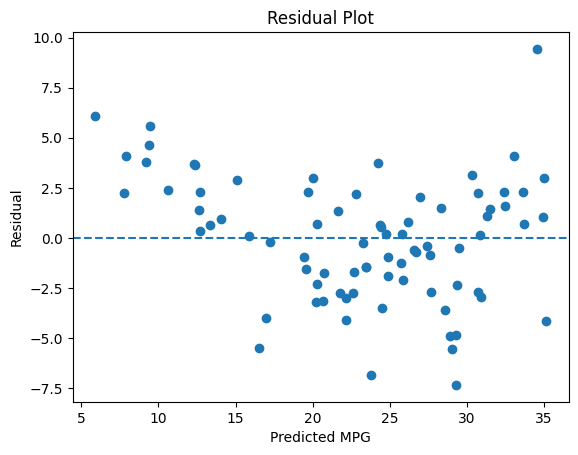

In [50]:
# Residual Plot
plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted MPG")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

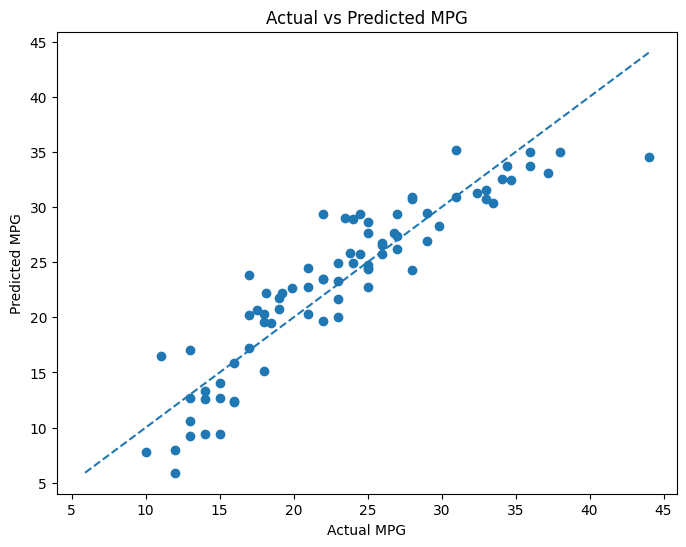

In [52]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")

plt.show()

In [54]:
# check training vs Testing Performance
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Training R²:", train_r2)
print("Testing R² :", test_r2)

Training R²: 0.8038978157245149
Testing R² : 0.8244245330943356


## Save the Model

In [56]:
joblib.dump(model,"linear_regression_car_mpg.pkl")

['linear_regression_car_mpg.pkl']